In [1]:
%matplotlib inline

torch.cuda.empty_cache()

In [3]:
pip install seaborn

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 1.0 MB/s eta 0:00:10
   --- ------------------------------------ 0.8/9.8 MB 1.3 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.8 MB 1.1 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.8 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.8 MB 1.2 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.8 MB 1.2 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.8 MB 1.3 MB/s eta 0:00:06
   --------- ------------------------------ 2.4/9.8 MB 1.3 MB/s eta 0:00:06
   ----------- ---------------------------- 2.9/9.8 MB 1.3 MB/s eta 0:00:06
   ------------ --------------------------- 3.1/9.8 MB 1.4 MB/s eta 0:00:05
   ------------- ----------------

In [4]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.backends.cudnn.benchmark = True

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti


In [ ]:

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATASET_DIR  = "Dataset"          # Root folder containing the 9 class subfolders
IMG_SIZE     = 224                # EfficientNet-B0 default input size
BATCH_SIZE   = 16
NUM_EPOCHS   = 70
LR           = 1e-4               # Fine-tuning learning rate
FREEZE_UNTIL = "features.4"       # Freeze all layers before this block
VAL_SPLIT    = 0.15               # 15% validation
TEST_SPLIT   = 0.10               # 10% test
NUM_WORKERS  = 0
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_PATH    = "best_efficientnet.pth"

CLASSES = [
    "Atelectasis", "Consolidation Lung", "COVID-19", "Edema",
    "Lungs Cancer", "Normal", "Pneumonia", "Pneumothorax", "Tuberculosis"
]
NUM_CLASSES = len(CLASSES)

print(f"Device: {DEVICE} | Classes: {NUM_CLASSES}")

Device: cuda | Classes: 9


In [38]:
# ─────────────────────────────────────────────
# TRANSFORMS
# ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
     transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),

])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [39]:
# ─────────────────────────────────────────────
# DATASET & SPLITS
# ─────────────────────────────────────────────
full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=train_transform)
print(f"Total samples: {len(full_dataset)}")
print(f"Class mapping: {full_dataset.class_to_idx}")

n_total = len(full_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_test  = int(n_total * TEST_SPLIT)
n_train = n_total - n_val - n_test

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)



Total samples: 204
Class mapping: {'Atelectasis': 0, 'COVID-19': 1, 'Consolidation Lung': 2, 'Edema': 3, 'Lungs Cancer': 4, 'Normal': 5, 'Pneumonia': 6, 'Pneumothorax': 7, 'Tuberculosis': 8}


In [40]:
# Apply val/test transform (no augmentation)
val_set.dataset.transform  = val_test_transform
test_set.dataset.transform = val_test_transform

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")

Train: 154 | Val: 30 | Test: 20


In [41]:

# ─────────────────────────────────────────────
# MODEL — EfficientNet-B0 Fine-Tuning
# ─────────────────────────────────────────────
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all layers up to FREEZE_UNTIL, unfreeze the rest
freeze = True
for name, param in model.named_parameters():
    if FREEZE_UNTIL in name:
        freeze = False
    param.requires_grad = not freeze

# Replace the final classifier head
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(DEVICE)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 3,953,347 / 4,019,077


In [42]:
# ─────────────────────────────────────────────
# LOSS, OPTIMIZER, SCHEDULER
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # label smoothing helps
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [43]:
# ─────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        tag = "  ← best"
    else:
        tag = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{tag}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f} — saved to {SAVE_PATH}")

Epoch 01/70 | Train Loss: 2.1887 Acc: 0.1299 | Val Loss: 2.1283 Acc: 0.2667  ← best
Epoch 02/70 | Train Loss: 1.9810 Acc: 0.3831 | Val Loss: 1.9835 Acc: 0.3333  ← best
Epoch 03/70 | Train Loss: 1.8468 Acc: 0.4805 | Val Loss: 1.8517 Acc: 0.2667
Epoch 04/70 | Train Loss: 1.7073 Acc: 0.5714 | Val Loss: 1.7620 Acc: 0.2667
Epoch 05/70 | Train Loss: 1.5909 Acc: 0.6299 | Val Loss: 1.7064 Acc: 0.2333
Epoch 06/70 | Train Loss: 1.4788 Acc: 0.6948 | Val Loss: 1.6517 Acc: 0.2667
Epoch 07/70 | Train Loss: 1.4010 Acc: 0.7078 | Val Loss: 1.6080 Acc: 0.3000
Epoch 08/70 | Train Loss: 1.3006 Acc: 0.7273 | Val Loss: 1.5929 Acc: 0.3000
Epoch 09/70 | Train Loss: 1.2426 Acc: 0.7532 | Val Loss: 1.5663 Acc: 0.3333
Epoch 10/70 | Train Loss: 1.1420 Acc: 0.7857 | Val Loss: 1.5832 Acc: 0.3333
Epoch 11/70 | Train Loss: 1.1061 Acc: 0.7662 | Val Loss: 1.6163 Acc: 0.3333
Epoch 12/70 | Train Loss: 1.0802 Acc: 0.7727 | Val Loss: 1.6409 Acc: 0.3333
Epoch 13/70 | Train Loss: 1.0511 Acc: 0.7792 | Val Loss: 1.6777 Acc: 0.3

In [45]:
# ─────────────────────────────────────────────
# EVALUATION ON TEST SET
# ─────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\n── Classification Report ──")
print(classification_report(all_labels, all_preds, target_names=CLASSES))


── Classification Report ──
                    precision    recall  f1-score   support

       Atelectasis       0.00      0.00      0.00         2
Consolidation Lung       0.00      0.00      0.00         2
          COVID-19       0.00      0.00      0.00         1
             Edema       1.00      1.00      1.00         1
      Lungs Cancer       0.50      0.20      0.29         5
            Normal       0.25      0.33      0.29         3
         Pneumonia       0.67      1.00      0.80         2
      Pneumothorax       0.00      0.00      0.00         0
      Tuberculosis       0.67      0.50      0.57         4

          accuracy                           0.35        20
         macro avg       0.34      0.34      0.33        20
      weighted avg       0.41      0.35      0.36        20



c:\Users\iziki\.conda\envs\project_python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\iziki\.conda\envs\project_python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\iziki\.conda\envs\project_python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", re

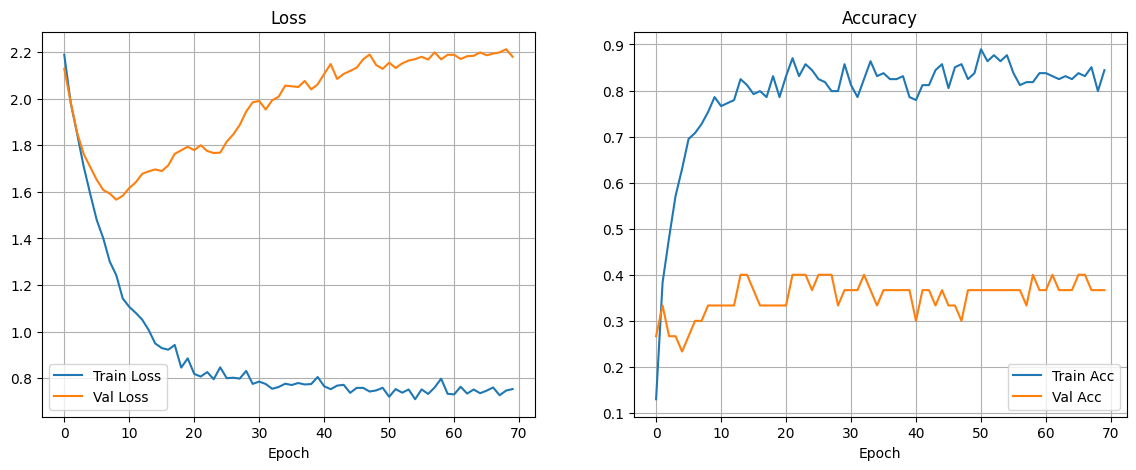

In [46]:
# ─────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

# Accuracy curve
axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"],   label="Val Acc")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

In [47]:


plt.tight_layout()
plt.savefig("training_curves.png")
print("Saved: training_curves.png")

Saved: training_curves.png


<Figure size 640x480 with 0 Axes>

Saved: confusion_matrix.png


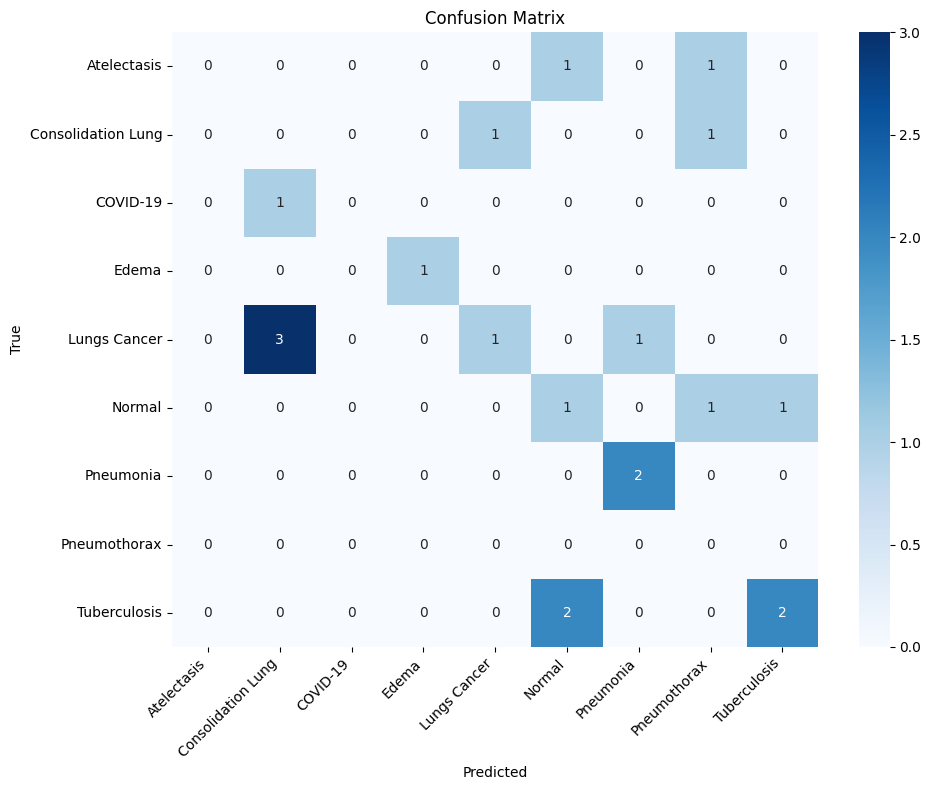

In [48]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
print("Saved: confusion_matrix.png")